In [152]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
import altair as alt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR

### Create dataframes

In [153]:
mood = pd.read_csv('../data/entry.csv', parse_dates=['DATE (YYYY-MM-DD)'], usecols=['DATE (YYYY-MM-DD)', 'IRRITABILITY', 'ANXIETY', 'DEPRESSED', 'ELEVATED']).rename(columns={'DATE (YYYY-MM-DD)':'day', 'IRRITABILITY':'irritable', 'ANXIETY':'anxious', 'DEPRESSED':'depressed','ELEVATED':'elevated'}).set_index('day')
#sleep = pd.read_csv('../data/dailysleep.csv', parse_dates=['day', 'bedtime_end', 'bedtime_start']).set_index('day')
sleep_scores = pd.read_csv('../data/dailysleep.csv', parse_dates=['day'], sep=';', usecols=['day', 'score']).set_index('day')
sleep_model = pd.read_csv(
    '../data/sleepmodel.csv', 
    sep=';', 
    parse_dates=['day'], 
    usecols=['day', 'average_heart_rate', 'average_hrv', 'hrv']
)

In [154]:
import pandas as pd
import numpy as np
import json

def robust_hrv_parse(hrv_val):
    if pd.isna(hrv_val) or hrv_val == "" or hrv_val == "{}":
        return pd.Series([np.nan, np.nan], index=['hrv_sdnn', 'hrv_restlessness'])
    
    try:
        # Oura sometimes uses single quotes or 'null', which JSON doesn't like. 
        # We'll fix the string to make it valid JSON if needed.
        if isinstance(hrv_val, str):
            clean_val = hrv_val.replace("'", '"').replace("None", "null")
            data = json.loads(clean_val)
        else:
            data = hrv_val
            
        items = [v for v in data.get('items', []) if v is not None]
        all_slots = data.get('items', [])
        
        if not items:
            return pd.Series([np.nan, np.nan], index=['hrv_sdnn', 'hrv_restlessness'])
            
        return pd.Series({
            'hrv_sdnn': np.std(items),
            'hrv_restlessness': all_slots.count(None) / len(all_slots) if all_slots else 0
        })
    except Exception:
        return pd.Series([np.nan, np.nan], index=['hrv_sdnn', 'hrv_restlessness'])

# Apply the fix
hrv_features = sleep_model['hrv'].apply(robust_hrv_parse)
sleep_model.update(hrv_features)

In [155]:
sleep_model

,average_heart_rate,average_hrv,day,hrv
0,60.625,31.0,2019-02-05,"{""interval"": 300.0, ""items"": [null, null, null..."
1,74.125,25.0,2019-02-06,"{""interval"": 300.0, ""items"": [null, null, null..."
2,74.000,26.0,2019-02-06,"{""interval"": 300.0, ""items"": [null, null, null..."
3,74.000,NaN,2019-02-06,"{""interval"": 300.0, ""items"": [null, null, null..."
4,68.250,36.0,2019-02-06,"{""interval"": 300.0, ""items"": [null, 49.0, 39.0..."
...,...,...,...,...
3803,0.000,NaN,2026-02-16,"{""interval"": 300.0, ""items"": [null, null, null..."
3804,69.750,34.0,2026-02-16,"{""interval"": 300.0, ""items"": [null, null, 33.0..."
3805,68.625,34.0,2026-02-17,"{""interval"": 300.0, ""items"": [null, 30.0, 38.0..."
3806,89.000,13.0,2026-02-17,"{""interval"": 300.0, ""items"": [null, null, null..."


In [156]:
def robust_hrv_parse(hrv_val):
    if pd.isna(hrv_val) or hrv_val == "" or hrv_val == "{}":
        return pd.Series([np.nan], index=['hrv_sdnn'])
    try:
        # Clean string for JSON parsing
        clean_val = hrv_val.replace("'", '"').replace("None", "null")
        data = json.loads(clean_val)
        items = [v for v in data.get('items', []) if v is not None]
        all_slots = data.get('items', [])
        
        sdnn = np.std(items) if len(items) > 1 else np.nan
        
        return pd.Series([sdnn], index=['hrv_sdnn'])
    except:
        return pd.Series([np.nan], index=['hrv_sdnn'])

# 1. Generate the features
hrv_features = sleep_model['hrv'].apply(robust_hrv_parse)

# 2. Join them explicitly to ensure columns exist
sleep_model = pd.concat([sleep_model, hrv_features], axis=1)

# 3. Handle the duplicate days and aggregate for VAR
sleep_model['day'] = pd.to_datetime(sleep_model['day'])

var_ready_sleep = sleep_model.groupby('day').agg({
    'average_heart_rate': 'mean',
    'average_hrv': 'mean',
    'hrv_sdnn': 'mean'
})

# 4. Ensure a continuous timeline (No missing days for VAR)
full_range = pd.date_range(start=var_ready_sleep.index.min(), 
                            end=var_ready_sleep.index.max(), 
                            freq='D')
var_ready_sleep = var_ready_sleep.reindex(full_range).interpolate(method='linear')

print("VAR Dataframe Shape:", var_ready_sleep.shape)
print(var_ready_sleep.head())

VAR Dataframe Shape: (2571, 3)
            average_heart_rate  average_hrv   hrv_sdnn
2019-02-05            60.62500         31.0   9.261629
2019-02-06            72.59375         29.0   8.169895
2019-02-07            64.00000         46.0  17.160808
2019-02-08            76.50000         25.0  14.782440
2019-02-09            62.25000         43.0  11.111641


In [157]:
import pandas as pd
import numpy as np

def analyze_data_integrity(df):
    """
    Analyzes and reports on the continuity and integrity of the time series.
    """
    results = {}
    total_obs = len(df)
    
    # 1. Basic Integrity: Missingness per Variable
    integrity_summary = pd.DataFrame({
        'Observed': df.count(),
        'Missing': df.isna().sum(),
        'Completion %': (df.count() / total_obs * 100).round(2)
    })
    
    # 2. Continuity: Check for Temporal Gaps
    # Assumes the index is a DatetimeIndex
    expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    missing_dates = expected_range.difference(df.index)
    
    # 3. Consecutive Missingness (Max Gap)
    # This is vital for VAR(6) to ensure lags aren't built on interpolated "ghost" data
    def get_max_gap(series):
        is_na = series.isna()
        return is_na.groupby(is_na.cumsum()).sum().max()

    gaps = df.apply(get_max_gap)
    integrity_summary['Max Consecutive Gap (Days)'] = gaps
    
    print("--- Data Integrity & Continuity Report ---")
    print(f"Total Theoretical Days in Range: {len(expected_range)} days")
    print(f"Total Observations in Dataframe: {total_obs} days")
    print(f"Explicitly Missing Dates in Index: {len(missing_dates)}")
    print("\nVariable-wise Integrity Statistics:")
    print(integrity_summary.to_string())
    
    if len(missing_dates) > 0:
        print(f"\nWarning: {len(missing_dates)} dates are missing from the time index.")
    
    return integrity_summary

# Run analysis on your target features
target_cols = ['hrv_anomaly', 'hrv_sdnn', 'anxious', 'depressed', 'irritable', 'elevated']
integrity_report = analyze_data_integrity(var_data[target_cols])

--- Data Integrity & Continuity Report ---
Total Theoretical Days in Range: 2565 days
Total Observations in Dataframe: 2565 days
Explicitly Missing Dates in Index: 0

Variable-wise Integrity Statistics:
             Observed  Missing  Completion %  Max Consecutive Gap (Days)
hrv_anomaly      2565        0         100.0                           0
hrv_sdnn         2565        0         100.0                           0
anxious          2565        0         100.0                           0
depressed        2565        0         100.0                           0
irritable        2565        0         100.0                           0
elevated         2565        0         100.0                           0


In [158]:
print(mood[mood[['irritable' ,'anxious','depressed','elevated']]>0].count().to_markdown())

|           |   0 |
|:----------|----:|
| irritable | 184 |
| anxious   | 141 |
| depressed | 219 |
| elevated  |  73 |


In [ ]:
ts = var_ready_sleep.join(mood, how='left').reindex(pd.date_range(var_ready_sleep.index.min(), var_ready_sleep.index.max(), freq='D')).fillna(0)

# hrv_anomaly is a 7-day rolling Z-score
ts['hrv_anomaly'] = (ts['average_hrv'] - ts['average_hrv'].rolling(7).mean()) / ts['average_hrv'].rolling(7).std()
ts

,average_heart_rate,average_hrv,hrv_sdnn,irritable,anxious,depressed,elevated,hrv_anomaly
2019-02-05,60.62500,31.0,9.261629,0.0,0.0,0.0,0.0,NaN
2019-02-06,72.59375,29.0,8.169895,0.0,0.0,0.0,0.0,NaN
2019-02-07,64.00000,46.0,17.160808,0.0,0.0,0.0,0.0,NaN
2019-02-08,76.50000,25.0,14.782440,0.0,0.0,0.0,0.0,NaN
2019-02-09,62.25000,43.0,11.111641,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...
2026-02-14,75.93750,40.0,11.395422,0.0,0.0,0.0,0.0,1.180604
2026-02-15,72.00000,21.0,9.057331,0.0,0.0,0.0,0.0,-0.964652
2026-02-16,34.87500,34.0,14.820232,0.0,0.0,0.0,0.0,0.569229
2026-02-17,78.81250,23.5,6.771076,0.0,0.0,0.0,0.0,-0.733473


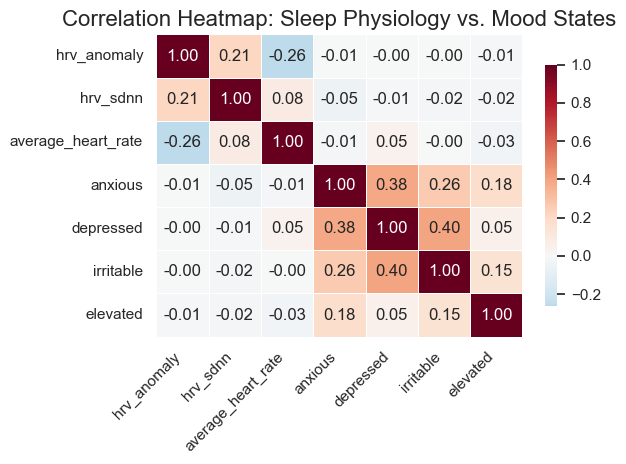

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_feature_correlation_heatmap(df):
    """
    Generates a heatmap to visualize the linear relationships between 
    physiological Oura metrics and EMA mood logs.
    """
    # Select the primary features for the heatmap
    # We include hrv_anomaly, hrv_restlessness, and all mood states
    cols_to_corr = [
        'hrv_anomaly', 'hrv_sdnn', 
        'average_heart_rate', 'anxious', 'depressed', 
        'irritable', 'elevated'
    ]
    
    # Calculate the correlation matrix
    corr_matrix = df[cols_to_corr].corr()
    
    # Set up the aesthetic parameters
    sns.set_theme(style="white")
    
    # Create the heatmap
    # cmap 'RdBu_r' is excellent for showing positive/negative correlations
    plt.gca().set_title('Correlation Heatmap: Sleep Physiology vs. Mood States', fontsize=16)
    
    sns.heatmap(
        corr_matrix, 
        annot=True,          # Show the correlation coefficients in the cells
        fmt=".2f",           # Format to 2 decimal places
        cmap='RdBu_r',       # Red for positive, Blue for negative
        center=0,            # Center the colormap at 0
        linewidths=.5,       # Add lines between cells
        cbar_kws={"shrink": .8}
    )
    
    # Ensure labels are readable
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # Save the plot
    plt.savefig('feature_correlation_heatmap.png')

# Usage:
plot_feature_correlation_heatmap(ts)

In [170]:
test_ts = ts['average_hrv']

# 1. Vector autoregression

## 1.1 Stationarity

In [162]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def check_ts_stationarity(df):
    """
    Runs the ADF test on all columns of the dataframe and returns a summary.
    """
    results = []
    
    for col in df.columns:
        # We drop NaNs as the ADF test cannot handle them
        dftest = adfuller(df[col].dropna(), autolag='AIC')
        
        p_value = dftest[1]
        is_stationary = p_value <= 0.05
        
        results.append({
            'Column': col,
            'ADF Statistic': round(dftest[0], 4),
            'p-value': round(p_value, 4),
            'Stationary?': '✅ Yes' if is_stationary else '❌ No (Needs Diff)'
        })
    
    return pd.DataFrame(results).set_index('Column')

# Usage:
stationarity_summary = check_ts_stationarity(ts)
print(stationarity_summary)

                    ADF Statistic  p-value Stationary?
Column                                                
average_heart_rate        -4.5930   0.0001       ✅ Yes
average_hrv               -4.4656   0.0002       ✅ Yes
hrv_sdnn                  -8.3414   0.0000       ✅ Yes
irritable                -32.8831   0.0000       ✅ Yes
anxious                  -11.9285   0.0000       ✅ Yes
depressed                -13.6867   0.0000       ✅ Yes
elevated                  -9.9551   0.0000       ✅ Yes
hrv_anomaly              -19.5072   0.0000       ✅ Yes


**Based on pmdarima ADF, choosing not to difference.**

## 1.2 ACF, PACF (average_hrv)

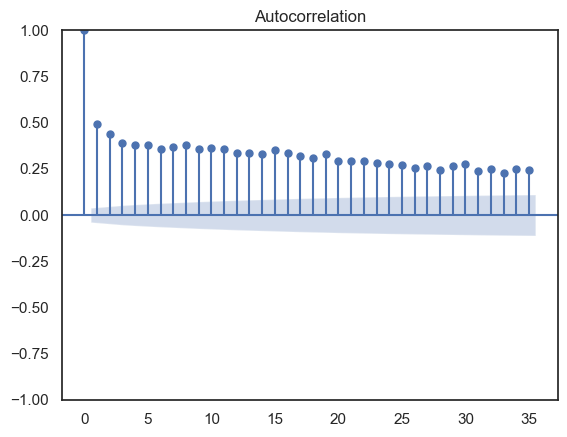

In [171]:
plot_acf(test_ts).savefig('plots/acf-hrv.png',dpi=300);

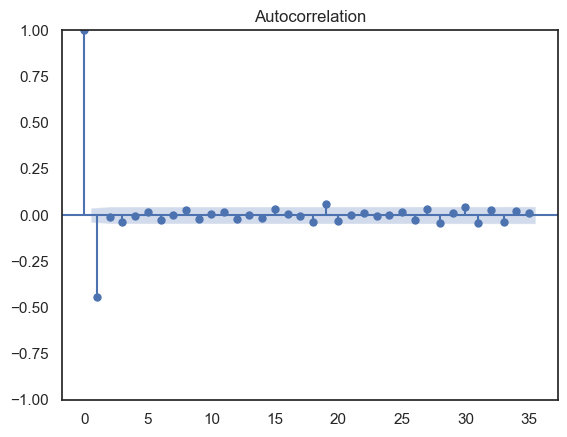

In [172]:
plot_acf(test_ts.diff(), missing='drop');

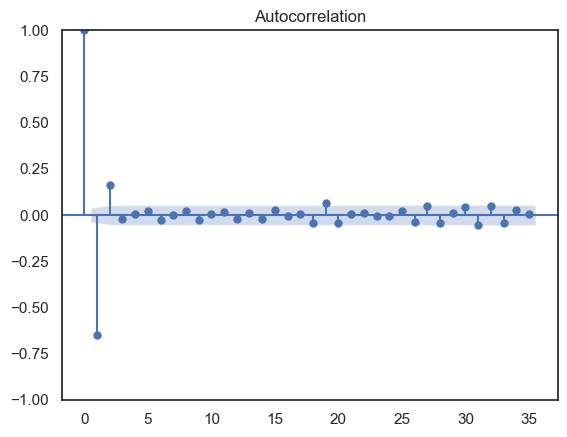

In [173]:
plot_acf(test_ts.diff().diff(), missing='drop');

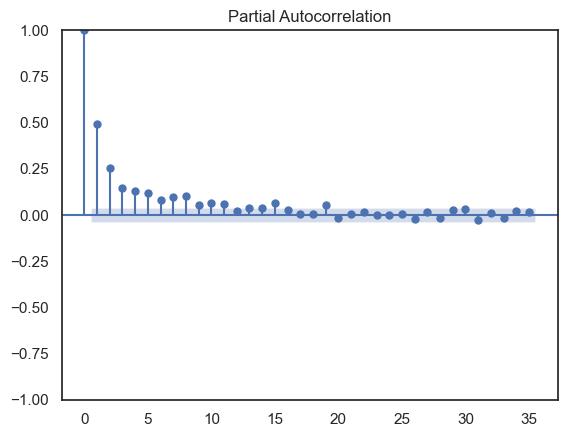

In [174]:
plot_pacf(test_ts).savefig('plots/pacf-hrv.png', dpi=300);

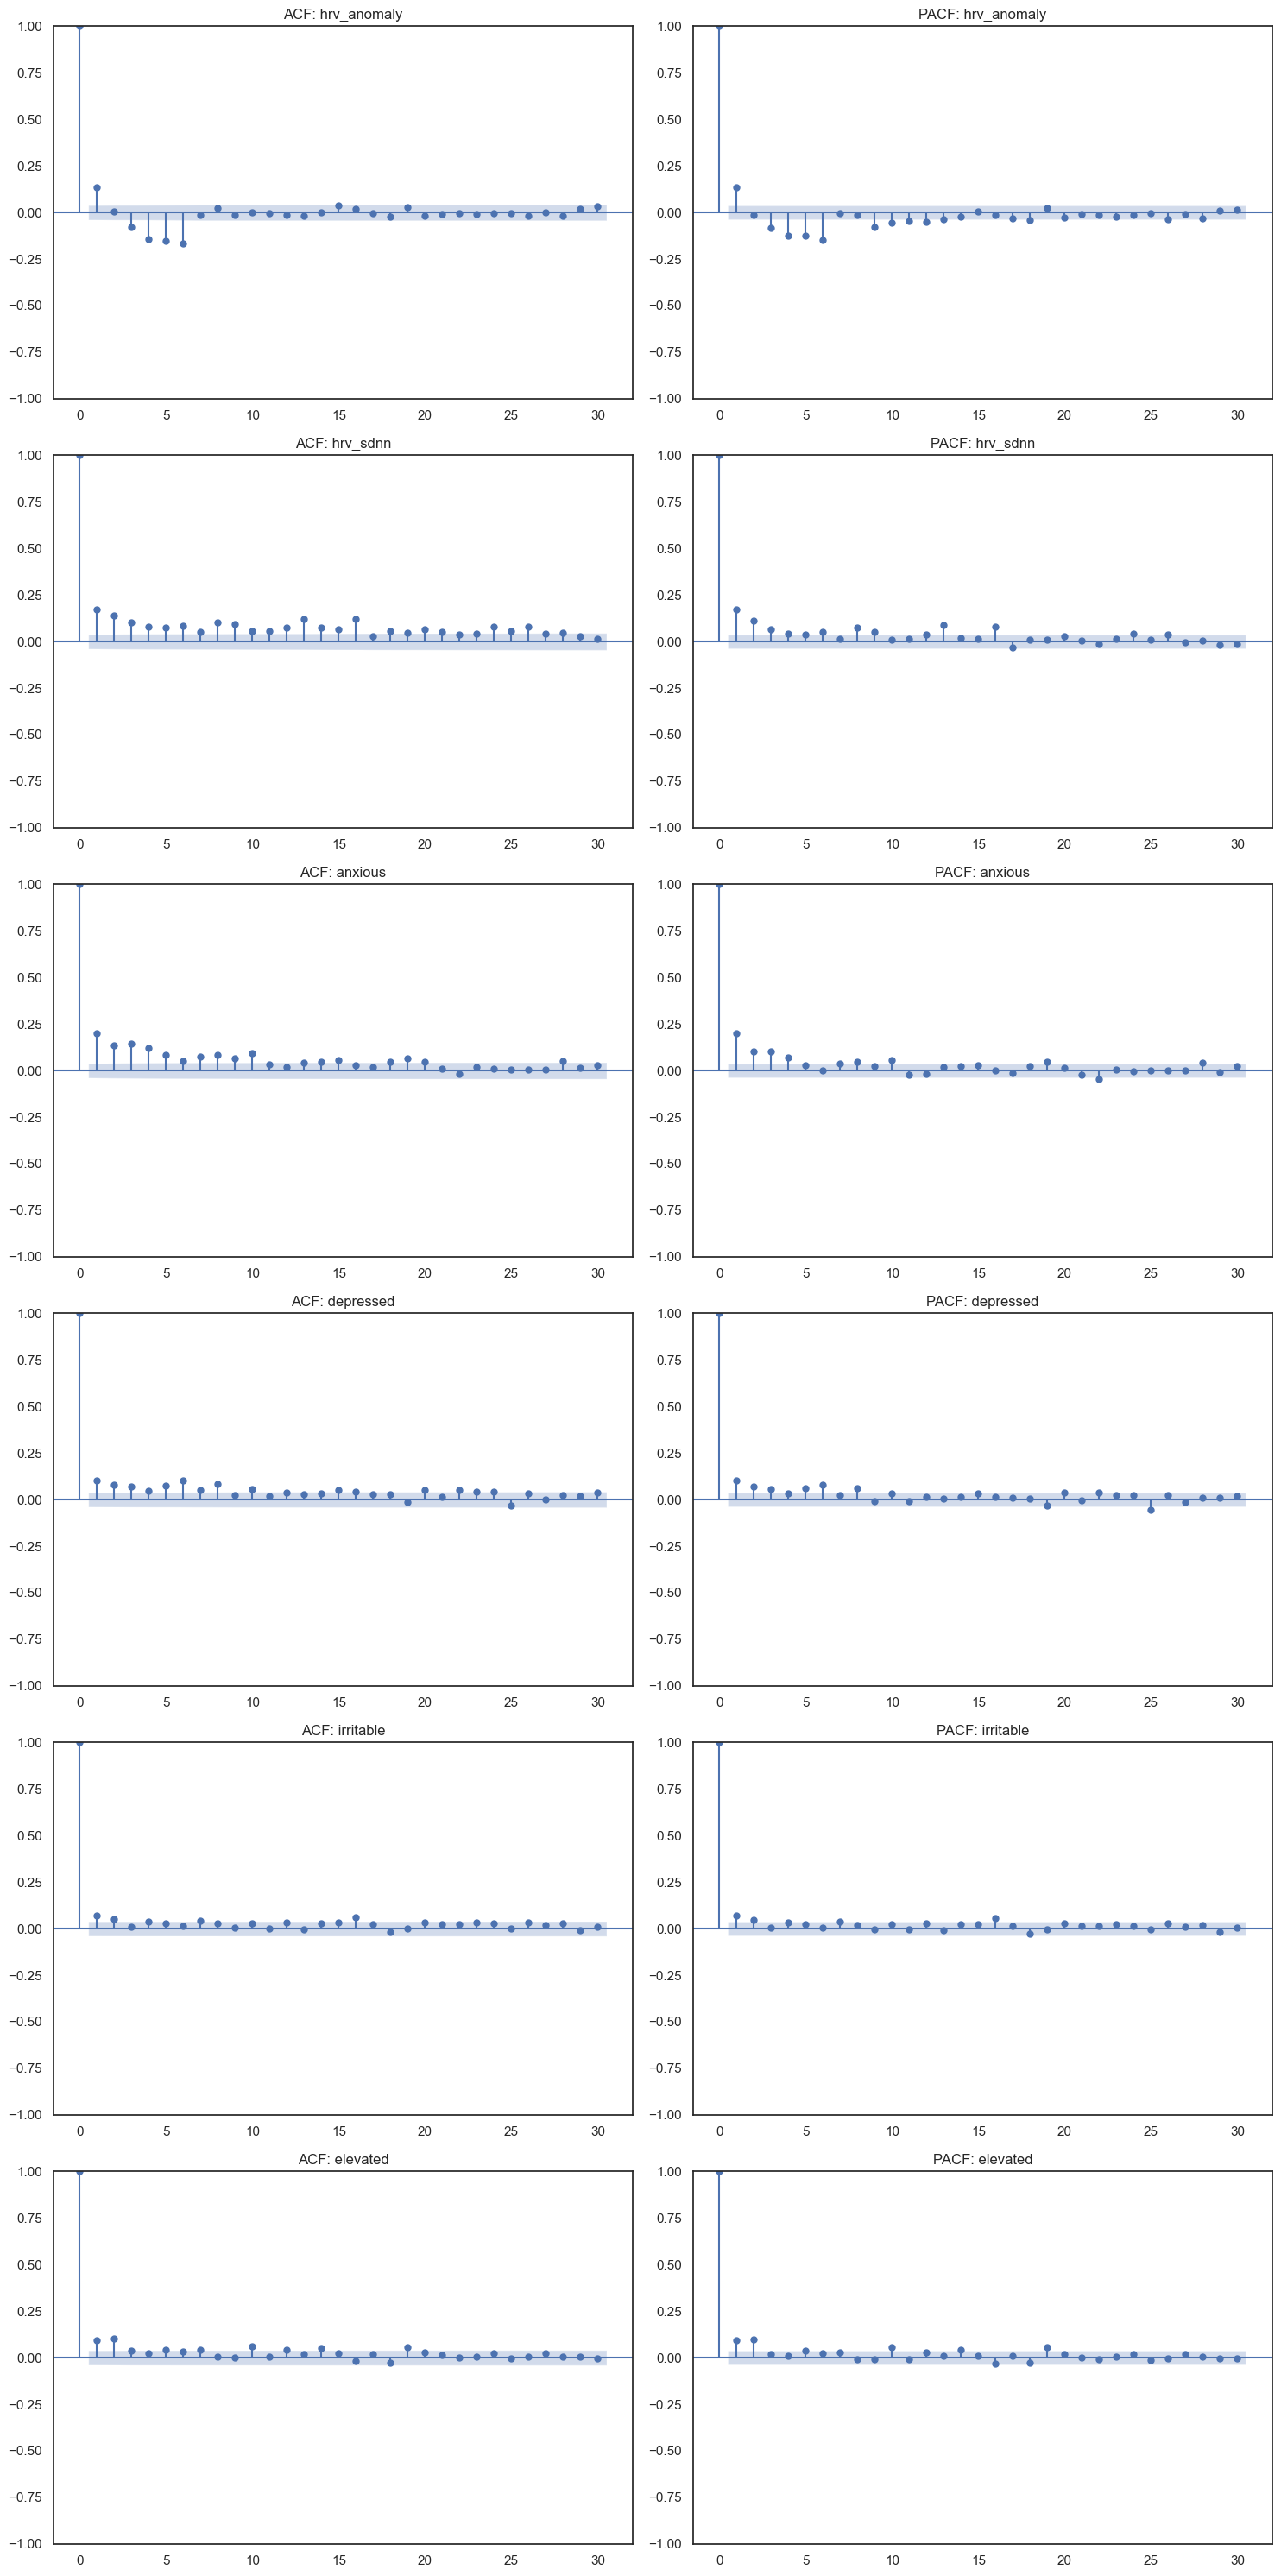

In [175]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_correlation_dynamics(df, columns, lags=30):
    """
    Plots ACF and PACF for specified columns to visualize time-dependency.
    """
    num_cols = len(columns)
    fig, axes = plt.subplots(num_cols, 2, figsize=(15, 5 * num_cols))
    
    for i, col in enumerate(columns):
        # ACF: Shows combined direct and indirect correlation
        plot_acf(df[col].dropna(), lags=lags, ax=axes[i, 0], title=f'ACF: {col}')
        
        # PACF: Shows only the direct correlation at that specific lag
        plot_pacf(df[col].dropna(), lags=lags, ax=axes[i, 1], title=f'PACF: {col}', method='ywm')
        
    plt.tight_layout()
    plt.show()

# Select key variables from your 'ts' dataframe
target_cols = ['hrv_anomaly', 'hrv_sdnn', 'anxious', 'depressed', 'irritable', 'elevated']
plot_correlation_dynamics(ts, target_cols)

## 1.3 Create VAR model

### 1.3.0 Lag order selection

In [ ]:
from statsmodels.tsa.api import VAR

model_var = VAR(ts[['hrv_anomaly', 'hrv_sdnn', 'anxious', 'depressed', 'irritable', 'elevated']].dropna())

# lag order selection
print(model_var.select_order(15).summary().as_latex_tabular())

\begin{center}
\begin{tabular}{lcccc}
\toprule
            & \textbf{AIC} & \textbf{BIC} & \textbf{FPE} & \textbf{HQIC}  \\
\midrule
\textbf{0}  &      -2.870  &      -2.856  &     0.05672  &       -2.865   \\
\textbf{1}  &      -2.967  &     -2.871*  &     0.05147  &      -2.932*   \\
\textbf{2}  &      -2.987  &      -2.809  &     0.05042  &       -2.923   \\
\textbf{3}  &      -2.995  &      -2.734  &     0.05002  &       -2.901   \\
\textbf{4}  &      -3.003  &      -2.660  &     0.04962  &       -2.879   \\
\textbf{5}  &      -3.012  &      -2.586  &     0.04917  &       -2.858   \\
\textbf{6}  &     -3.036*  &      -2.527  &    0.04802*  &       -2.852   \\
\textbf{7}  &      -3.034  &      -2.442  &     0.04814  &       -2.819   \\
\textbf{8}  &      -3.032  &      -2.358  &     0.04823  &       -2.788   \\
\textbf{9}  &      -3.032  &      -2.275  &     0.04824  &       -2.757   \\
\textbf{10} &      -3.029  &      -2.190  &     0.04838  &       -2.724   \\
\textbf{11} &      -

### 1.3.1 VAR(1) model

In [ ]:
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Fit the simpler Lag 1 model (BIC's choice)
model = VAR(var_data)
results_lag1 = model.fit(1)

# 2. Run the Multivariate Whiteness Test
# We check up to 10 lags ahead to see if any delayed signals were missed
whiteness_test = results_lag1.test_whiteness(nlags=10, adjusted=True)

print("--- Multivariate Portmanteau Test ---")
print(whiteness_test.summary())
print("\n")

# 3. Univariate Ljung-Box Test (To see exactly WHICH equation is leaking signal)
print("--- Univariate Ljung-Box Tests (p-values) ---")
for col in results_lag1.names:
    # Testing for remaining autocorrelation at 10 lags
    lb_test = acorr_ljungbox(results_lag1.resid[col], lags=[10], return_df=True)
    p_val = lb_test['lb_pvalue'].values[0]
    
    status = "✅ Clean (White Noise)" if p_val > 0.05 else "❌ Signal Left Behind"
    print(f"{col:<15}: {p_val:.4f}  {status}")

--- Multivariate Portmanteau Test ---
Adjusted Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         808.0          367.0   0.000 324
-----------------------------------------


--- Univariate Ljung-Box Tests (p-values) ---
hrv_anomaly    : 0.0000  ❌ Signal Left Behind
hrv_sdnn       : 0.0000  ❌ Signal Left Behind
anxious        : 0.0000  ❌ Signal Left Behind
depressed      : 0.0000  ❌ Signal Left Behind
irritable      : 0.0614  ✅ Clean (White Noise)
elevated       : 0.0000  ❌ Signal Left Behind


In [ ]:
# Select the new feature set
# Note: hrv_anomaly likely has 6-7 NaNs at the start due to the rolling window
var_data = ts[['hrv_anomaly', 'hrv_sdnn', 'anxious', 'depressed', 'irritable', 'elevated']].dropna()

model = VAR(var_data)
results = model.fit(maxlags=6)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 08, Mar, 2026
Time:                     14:59:43
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -2.54412
Nobs:                     2559.00    HQIC:                  -2.86745
Log likelihood:          -17660.1    FPE:                  0.0472935
AIC:                     -3.05139    Det(Omega_mle):       0.0433906
--------------------------------------------------------------------
Results for equation hrv_anomaly
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                 -0.084552         0.120860           -0.700           0.484
L1.hrv_anomaly         0.081124         0.020106            4.035           0.000
L1.hrv_sdnn            0.010526         0.004911  

### 1.3.2 VAR(6) model

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Run the Multivariate Whiteness Test on the Lag 6 model
# We test up to 12 lags to ensure we look well past the 6-day window
whiteness_test_lag6 = results.test_whiteness(nlags=12, adjusted=True)

print("--- Multivariate Portmanteau Test (Lag 6) ---")
print(whiteness_test_lag6.summary())
print("\n")

# 2. Univariate Ljung-Box Test for the Lag 6 residuals
print("--- Univariate Ljung-Box Tests (p-values) ---")
for col in results.names:
    # Testing for remaining autocorrelation at 12 lags
    lb_test = acorr_ljungbox(results.resid[col], lags=[12], return_df=True)
    p_val = lb_test['lb_pvalue'].values[0]
    
    status = "✅ Clean (White Noise)" if p_val > 0.05 else "❌ Signal Left Behind"
    print(f"{col:<15}: {p_val:.4f}  {status}")

--- Multivariate Portmanteau Test (Lag 6) ---
Adjusted Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         351.5          251.3   0.000 216
-----------------------------------------


--- Univariate Ljung-Box Tests (p-values) ---
hrv_anomaly    : 0.0004  ❌ Signal Left Behind
hrv_sdnn       : 0.1773  ✅ Clean (White Noise)
anxious        : 0.1374  ✅ Clean (White Noise)
depressed      : 0.3747  ✅ Clean (White Noise)
irritable      : 0.8837  ✅ Clean (White Noise)
elevated       : 0.4194  ✅ Clean (White Noise)


## 1.4 Granger Causality

In [ ]:
import pandas as pd
import warnings
from statsmodels.tsa.stattools import grangercausalitytests

warnings.filterwarnings('ignore', category=FutureWarning)

def perform_comprehensive_granger_tests(df, causing_cols, affected_cols, maxlag=6):
    """
    Tests Granger causality across a matrix of causing and affected variables,
    printing the results cleanly for up to maxlag days.
    """
    print(f"🔬 RUNNING GRANGER CAUSALITY MATRIX (Max Lag: {maxlag} days)\n")
    
    for affected in affected_cols:
        print(f"{'='*50}")
        print(f"🎯 TARGET MOOD: {affected.upper()}")
        print(f"{'='*50}")
        
        for causing in causing_cols:
            # Skip testing a variable against itself
            if causing == affected:
                continue 
            
            print(f"\n--- Testing if '{causing}' Granger-causes '{affected}' ---")
            
            # statsmodels expects a 2D array [affected, causing]
            test_result = grangercausalitytests(df[[affected, causing]], maxlag=maxlag, verbose=False)
            
            # Track if we found any significance to keep the summary readable
            found_significance = False
            
            for lag in range(1, maxlag + 1):
                p_val = test_result[lag][0]['ssr_ftest'][1]
                
                if p_val < 0.05:
                    print(f"Lag {lag}: p-value = {p_val:.4f} (✅ SIGNIFICANT)")
                    found_significance = True
                else:
                    print(f"Lag {lag}: p-value = {p_val:.4f} (❌ Not Significant)")
            
            if not found_significance:
                print("-> No predictive causality found across any lag.")

# --- Execution ---
# Define all inputs (physiology + past mood) and all targets (future mood)
all_predictors = ['hrv_anomaly', 'hrv_sdnn', 'anxious', 'depressed', 'irritable', 'elevated']
target_moods = ['anxious', 'depressed', 'irritable', 'elevated']

# Run the automated matrix on your dataset
perform_comprehensive_granger_tests(var_data, all_predictors, target_moods, maxlag=6)

🔬 RUNNING GRANGER CAUSALITY MATRIX (Max Lag: 6 days)

🎯 TARGET MOOD: ANXIOUS

--- Testing if 'hrv_anomaly' Granger-causes 'anxious' ---
Lag 1: p-value = 0.8841 (❌ Not Significant)
Lag 2: p-value = 0.9847 (❌ Not Significant)
Lag 3: p-value = 0.9412 (❌ Not Significant)
Lag 4: p-value = 0.9688 (❌ Not Significant)
Lag 5: p-value = 0.9776 (❌ Not Significant)
Lag 6: p-value = 0.9828 (❌ Not Significant)
-> No predictive causality found across any lag.

--- Testing if 'hrv_sdnn' Granger-causes 'anxious' ---
Lag 1: p-value = 0.2113 (❌ Not Significant)
Lag 2: p-value = 0.3097 (❌ Not Significant)
Lag 3: p-value = 0.4832 (❌ Not Significant)
Lag 4: p-value = 0.6519 (❌ Not Significant)
Lag 5: p-value = 0.7812 (❌ Not Significant)
Lag 6: p-value = 0.8228 (❌ Not Significant)
-> No predictive causality found across any lag.

--- Testing if 'depressed' Granger-causes 'anxious' ---
Lag 1: p-value = 0.9312 (❌ Not Significant)
Lag 2: p-value = 0.5078 (❌ Not Significant)
Lag 3: p-value = 0.0176 (✅ SIGNIFICAN

## 1.5 Visualization: Impulse Response Function

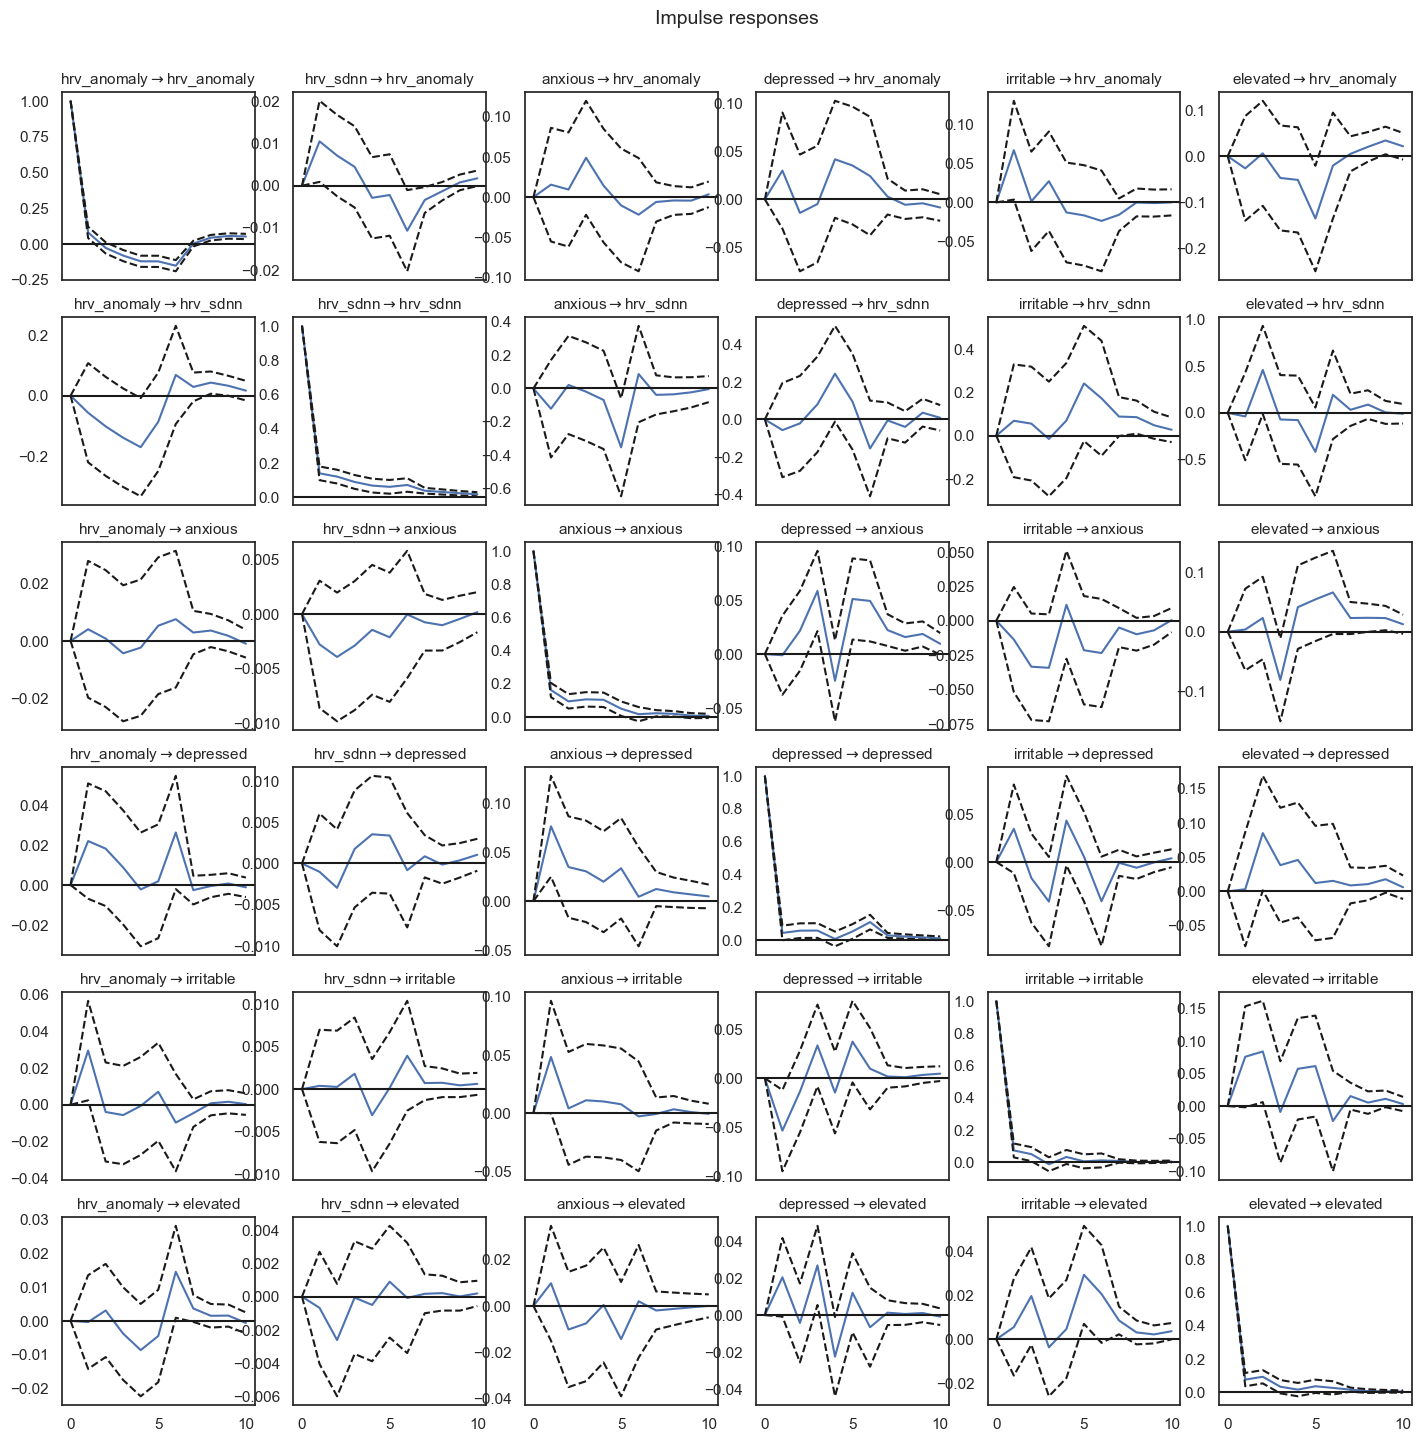

In [ ]:
irf = results.irf(10)

irf.plot(orth=False, figsize=(15,15), subplot_params={'fontsize': 11});